## Plan de travail
- **Partie 1 :** implémentation d"une couche GAT single-head en NumPy (Exos 1.1 → 1.4 + Quiz 1.1).
- **Partie 2 :** architecture GAT PyG sur Cora, entraînement + Quiz 2.1.
- **Partie 3 :** extraction et visualisation des poids d"attention.
- **Partie 4 :** comparaison GCN / GAT / GATv2 (perf & temps).
- **Annexes :** rapport synthétique + section sur l"usage du GenAI.

In [39]:
# Chargement des dépendances principales et du dataset Cora pour PyG
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GATConv, GCNConv, GATv2Conv
from torch_geometric.utils import to_networkx
import networkx as nx
import time
import pandas as pd



torch.manual_seed(42)
np.random.seed(42)
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)
DATA_ROOT = "Cora"
dataset = Planetoid(root=DATA_ROOT, name="Cora", transform=NormalizeFeatures())
data = dataset[0]
print(dataset)
print(data)

Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


/home/pierre/Desktop/epita/maj/ing3/stochastique/.venv/lib/python3.12/site-packages/torch_geometric/data/in_memory_dataset.py:131: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  out = fs.torch_load(path)


## Partie 1 · NumPy GAT (Exos 1.1 → 1.4)
Compléter progressivement la classe `GATLayerNumPy` ci-dessous : initialisation Xavier, LeakyReLU, coefficients d"attention masqués par l"adjacence et passage avant complet. Chaque TODO renvoie au numéro d"exercice correspondant. Pensez à documenter les réponses aux quiz directement sous les cellules concernées.

In [40]:
import math

class GATLayerNumPy:
    """Couche GAT single-head en NumPy utilisée dans la Partie 1.

    Les méthodes sont à compléter suivant les exercices décrits dans 3-GAT.md.
    """

    def __init__(self, in_features: int, out_features: int, alpha: float = 0.2):
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        limit = math.sqrt(6.0 / (in_features + out_features))
        rng = np.random.default_rng(42)
        self.W = rng.uniform(-limit, limit, size=(in_features, out_features))  # Exo 1.1
        self.a = rng.uniform(-limit, limit, size=(2 * out_features, 1))        # Exo 1.1

    @staticmethod
    def leaky_relu(x, negative_slope: float = 0.2):
        """Exo 1.2 : implémenter la variante NumPy du LeakyReLU."""
        return np.where(x >= 0, x, negative_slope * x)

    @staticmethod
    def masked_softmax(logits: np.ndarray, mask: np.ndarray):
        """Utilitaire pour appliquer un softmax stable en ne gardant que les voisins (mask = adj)."""
        masked_logits = np.where(mask, logits, -1e9)
        shifted = masked_logits - masked_logits.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted) * mask
        denom = exp_scores.sum(axis=1, keepdims=True) + 1e-16
        return exp_scores / denom

    def compute_attention_coefficients(self, h: np.ndarray, adj: np.ndarray):
        """Exo 1.3 : calculer e_ij, appliquer LeakyReLU, masquer avec adj, puis normaliser."""
        a_l = self.a[: self.out_features]
        a_r = self.a[self.out_features :]
        f_i = h @ a_l  # (N, 1)
        f_j = h @ a_r  # (N, 1)
        logits = f_i + f_j.T
        logits = self.leaky_relu(logits, self.alpha)
        mask = adj.astype(bool)
        return self.masked_softmax(logits, mask)

    def forward(self, features: np.ndarray, adj: np.ndarray, activation=np.tanh):
        """Exo 1.4 : propager les features via l'aggrégation attentionnelle puis activer."""
        h = features @ self.W
        attention = self.compute_attention_coefficients(h, adj)
        aggregated = attention @ h
        return activation(aggregated) if activation is not None else aggregated

Quiz 1.1
Question: Why do we need to mask attention coefficients using the adjacency matrix?
- To normalize the attention weights

## Partie 2 · Pipeline PyG GAT
Définir ensuite l"architecture `GAT` (2 couches GATConv), la fonction `train()` et les métriques de validation / test. Utiliser les blocs ci-dessous pour structurer l"implémentation avant de passer à la visualisation des poids (Partie 3).

> Astuce : préparez aussi une cellule dédiée aux hyperparamètres pour faciliter les comparaisons ultérieures (Partie 4).

In [ ]:
class GAT(nn.Module):
    """Exercices 2.1-2.2 : architecture GAT PyG (2 couches)."""

    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 heads: int = 8, dropout: float = 0.6):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=self.dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False,dropout=self.dropout)
        self.epoch = 0

    def forward(self, data):
        """Exercice 2.2 : passe avant avec dropout + GATConv + log_softmax."""
        x = F.dropout(data.x, p=self.dropout, training=self.training)
        x = self.conv1(x, data.edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x , alpha = self.conv2(x, data.edge_index, return_attention_weights=True)
        return F.log_softmax(x, dim=1) , alpha
    
    def train_step(self, data, optimizer):
        """Exercice 2.3 : boucle d'entraînement sur les masques d'apprentissage."""
        self.train()
        optimizer.zero_grad()
        out, _ = self(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        if self.epoch % 20 == 0:
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
            pred = out.argmax(dim=1)
            train_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
            val_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
            print(f'Epoch {self.epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {train_acc*100:>5.2f}% | Val Acc: {val_acc*100:.2f}%')
        self.epoch += 1
        return loss.item()

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out, _ = self(data)
        pred = out.argmax(dim=1) 
        
        accs = {}
        for key, mask in [('train', data.train_mask), ('val', data.val_mask), ('test', data.test_mask)]:
            correct = pred[mask] == data.y[mask]
            accs[key] = int(correct.sum()) / int(mask.sum())
        return accs
    
    def evaluate(self, data, optimizer: torch.optim.Optimizer,epochs: int = 200):
        """Boucle d'entraînement simplifiée."""
        for _ in range(epochs):
            loss = self.train_step(data, optimizer)
 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GAT(dataset.num_features, 8, dataset.num_classes).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

Quiz 2.1
Question: Why is dropout particularly important for GAT models?
- GATs have many parameters and tend to overfit on small datasets

## Partie 3 · Visualisation des poids d'attention
Préparer les structures nécessaires pour extraire, analyser et visualiser les poids d'attention (Exos 3.1 → 3.3).
Chaque sous-exercice disposera d'une méthode dédiée dans une classe utilitaire pour garder la logique organisée.

  - Tête 0: Mean=0.2035, Std=0.3137 (Discriminante)
  - Tête 1: Mean=0.2091, Std=0.3179 (Discriminante)
  - Tête 2: Mean=0.2029, Std=0.3142 (Discriminante)
  - Tête 3: Mean=0.2097, Std=0.3140 (Discriminante)
  - Tête 4: Mean=0.2053, Std=0.3156 (Discriminante)
  - Tête 5: Mean=0.2005, Std=0.3110 (Discriminante)
  - Tête 6: Mean=0.2011, Std=0.3114 (Discriminante)
  - Tête 7: Mean=0.2026, Std=0.3131 (Discriminante)


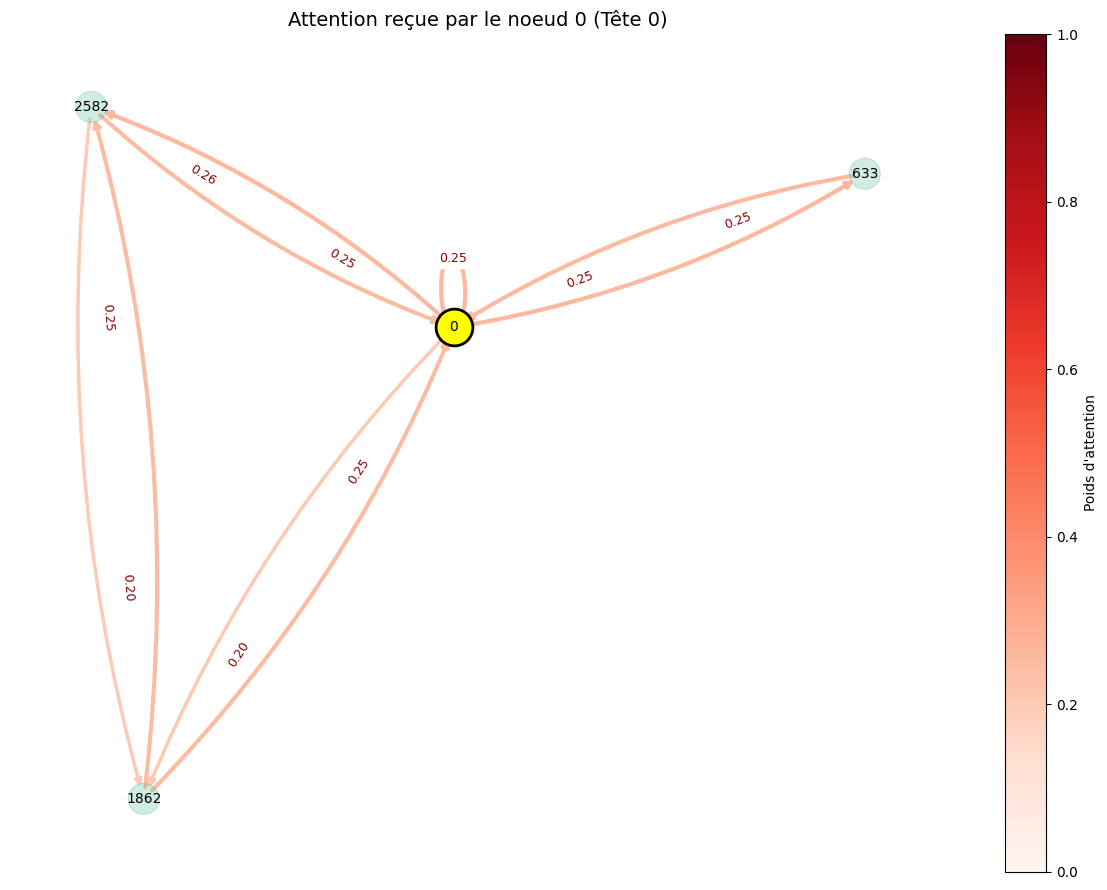

In [42]:

class AttentionInspector:
    """Exercices 3.1-3.3 : extraction, analyse et visualisation des poids d'attention."""

    def __init__(self, model, data):
        self.model = model
        self.data = data
        self.cached_attention = None

    def extract_attention_weights(self, layer_idx: int = 0):
        """Exercice 3.1 : utiliser return_attention_weights=True pour extraire les poids."""
        with torch.no_grad():
            device = next(self.model.parameters()).device
            x = self.data.x.to(device)
            edge_index = self.data.edge_index.to(device)
            
            if layer_idx == 0:
                
                _, (edge_index_alpha, alpha) = self.model.conv1(x, edge_index, return_attention_weights=True)
                self.cached_attention = alpha.cpu()
                return edge_index_alpha.cpu(), alpha.cpu()
            else:
                _, (edge_index_alpha, alpha) = self.model(self.data.to(device))
                self.cached_attention = alpha.cpu()
                return edge_index_alpha.cpu(), alpha.cpu()

    def describe_attention_statistics(self):
        """Exercice 3.2 : calculer statistiques (moyenne/écart-type) par tête."""
        if self.cached_attention != None:
            num_heads = self.cached_attention.shape[1]
            for h in range(num_heads):
                mean_att = self.cached_attention[:, h].mean().item()
                std_att = self.cached_attention[:, h].std().item()
                print(f"  - Tête {h}: Mean={mean_att:.4f}, Std={std_att:.4f} "
                    f"{'(Discriminante)' if std_att > 0.1 else '(Uniforme)'}")

    def visualize_attention(self, node_idx: int, head: int = 0):
        """Exercice 3.3 : visualiser les poids d'attention reçus par un noeud donné."""
        training_state = self.model.training
        self.model.eval()

        G_full = to_networkx(self.data, to_undirected=False)
        
        try:
            neighbors = list(G_full.predecessors(node_idx))
        except:
            neighbors = list(G_full.neighbors(node_idx))
            
        neighbors.append(node_idx)
        G = G_full.subgraph(neighbors).copy()
        
        edge_index_alpha, alpha = self.extract_attention_weights(layer_idx=0)
        
        att_dict = {}
        alpha_cpu = alpha.detach().cpu().numpy()
        src_cpu = edge_index_alpha[0].cpu().numpy()
        dst_cpu = edge_index_alpha[1].cpu().numpy()
        
        
        for s, d, w in zip(src_cpu, dst_cpu, alpha_cpu):
            att_dict[(int(s), int(d))] = w[head]

        self.model.train(training_state)

        if (node_idx, node_idx) in att_dict:
             if not G.has_edge(node_idx, node_idx):
                 G.add_edge(node_idx, node_idx)

        fig, ax = plt.subplots(1, 1, figsize=(12, 9))
        pos = nx.spring_layout(G, seed=42, k=0.5) 
        
        if self.data.y is not None:
            labels = self.data.y.cpu().numpy()
            node_colors = [labels[i] for i in G.nodes()]
        else:
            node_colors = 'blue'

        conn_style = "arc3,rad=0.1"
        edge_colors_list = []
        edge_widths_list = []
        edge_labels_dict = {}
        
        found_values = 0

        for edge in G.edges():
            s, t = edge

            att = att_dict.get((s, t), 0.0)
            
            if att > 0: found_values += 1
            
            edge_colors_list.append(att)
            edge_widths_list.append(att * 10 + 0.5)
            
            if att < 0.01:
                edge_labels_dict[(s, t)] = "< 0.01"
            else:
                edge_labels_dict[(s, t)] = f"{att:.2f}"

        if found_values == 0:
            print("Aucune attention trouvée.")
        # l'attention d'une edge se trouve le plus pres du noeud cible

        nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2,
                               node_size=500, alpha=0.3, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[node_idx], 
                               node_color='yellow', node_size=700, 
                               edgecolors='black', linewidths=2, ax=ax)

        nx.draw_networkx_edges(G, pos, width=edge_widths_list, 
                               edge_color=edge_colors_list, 
                               edge_cmap=plt.cm.Reds, 
                               edge_vmin=0.0, edge_vmax=1.0,
                               arrows=True, connectionstyle=conn_style,
                               ax=ax)
        
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_dict, 
                                     font_color='darkred', font_size=9, 
                                     label_pos=0.7,
                                     ax=ax)

        nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
        
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0.0, vmax=1.0))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Poids d'attention")

        ax.set_title(f"Attention reçue par le noeud {node_idx} (Tête {head})", fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        return fig


inspector = AttentionInspector(model, data)

ei, alpha = inspector.extract_attention_weights(layer_idx=0)
inspector.describe_attention_statistics()

try:
    inspector.visualize_attention(node_idx=0, head=0) 
except Exception as e:
    print(f"Erreur visualisation : {e}")

## Partie 4 · Comparaison GCN / GAT / GATv2
Structurer les expériences de comparaison (perf, temps, analyse des poids) en définissant une classe de pilotage dédiée aux Exos de la Partie 4.

In [43]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out, learning_rate=0.01, weight_decay=5e-4):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                # Affichage optionnel pendant l'entraînement
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                pred = out.argmax(dim=1)
                train_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
                val_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {train_acc*100:>5.2f}% | Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        
        accs = {}
        for key, mask in [('train', data.train_mask), ('val', data.val_mask), ('test', data.test_mask)]:
            correct = pred[mask] == data.y[mask]
            accs[key] = int(correct.sum()) / int(mask.sum())
        return accs

In [44]:
class GATv2(torch.nn.Module):
    def __init__(self, in_c, hid_c, out_c, heads=8, learning_rate=0.005, weight_decay=5e-4):
        super().__init__()
        self.conv1 = GATv2Conv(in_c, hid_c, heads=heads, dropout=0.6)
        self.conv2 = GATv2Conv(hid_c * heads, out_c, heads=1, concat=False, dropout=0.6)
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x, alpha = self.conv2(x, edge_index, return_attention_weights=True)
        return F.log_softmax(x, dim=1), alpha

    def fit(self, data, epochs):
        criterion = torch.nn.NLLLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            # Note: GATv2Conv expects data object or x, edge_index depending on implementation. 
            # Here we conform to the forward signature: forward(data)
            out, _ = self(data) 
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                pred = out.argmax(dim=1)
                train_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
                val_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {train_acc*100:>5.2f}% | Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        """Évaluation standard."""
        self.eval()
        out, _ = self(data)
        pred = out.argmax(dim=1)
        accs = {}
        for key, mask in [('train', data.train_mask), ('val', data.val_mask), ('test', data.test_mask)]:
            correct = pred[mask] == data.y[mask]
            accs[key] = int(correct.sum()) / int(mask.sum())
        return accs

In [47]:
class ModelComparisonSuite:
    """Partie 4 : comparer GCN, GAT et GATv2 sur plusieurs jeux de données."""


    def __init__(self, dataset, num_features : int = None, num_classes : int = None,device: torch.device | None = None):
        self.dataset = dataset
        self.num_features = num_features or dataset.num_features
        self.num_classes = num_classes or dataset.num_classes
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.results = None


    def configure_run(self, model_name: str, hyperparams: dict):
        """Préparer une expérimentation (choix modèle + hyperparamètres)."""
        params_hidden = hyperparams.get('hidden_dimension', 16)

        if model_name == 'GCN':
            params_lr = hyperparams.get('learning_rate', 0.01)
            params_wd = hyperparams.get('weight_decay', 5e-4)
            return GCN(self.num_features, params_hidden, self.num_classes,learning_rate=params_lr,weight_decay=params_wd)
        
        elif model_name == 'GATv1':
            params_heads = hyperparams.get('heads', 8)
            return GAT(self.num_features, params_hidden, self.num_classes, heads=params_heads)
            
        elif model_name == 'GATv2':
            params_lr = hyperparams.get('learning_rate', 0.005)
            params_wd = hyperparams.get('weight_decay', 5e-4)
            return GATv2(self.num_features, params_hidden, self.num_classes,learning_rate=params_lr,weight_decay=params_wd)


    def benchmark(self,hyperparams: dict):
        """Lancer les entraînements, collecter perf/temps/attention selon les exercices."""
        model_names = ['GCN', 'GATv1', 'GATv2']
        results_list = []
        data = self.dataset[0].to(self.device)

        for name in model_names:
            print("-" * 30)
            model = self.configure_run(name, hyperparams)
            start_time = time.time()
            if (name != 'GATv1'):
                model.fit(data, hyperparams.get('epochs', 200))
            else : 
                optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
                for _ in range(hyperparams.get('epochs', 200)):
                    model.train_step(data, optimizer)
            
            end_time = time.time()
            duration = end_time - start_time
            
            acc = model.test(data)
            
            results_list.append({
                'Model': name,
                'Train Acc': acc['train'],
                'Val Acc': acc['val'],
                'Test Acc': acc['test'],
                'Training Time (s)': duration
            })

        self.results = pd.DataFrame(results_list)

    def summarize(self):
        """Retourner un tableau/rapport synthétique des métriques collectées."""
        return self.results


In [48]:
# This cell initializes and runs the ModelComparisonSuite.
# It defines the hyperparameters, runs the benchmark, and displays the summary.

# --- Configuration ---
# You can adjust these hyperparameters to explore different settings.
hyperparameters = {
    'epochs': 200,             # Number of training epochs
    'learning_rate': 0.005,    # Learning rate for optimizers
    'weight_decay': 5e-4,      # Weight decay (L2 regularization)
    'hidden_dimension': 8,    # Hidden dimension size (for GATs, output dim per head usually)
    'heads': 8                 # Number of attention heads for GAT models
}

# --- Launch Benchmark ---
print("Initializing Model Comparison Suite...")
# Assuming 'dataset' is already loaded from previous cells (e.g., Cora)
# If not, you might need: dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
suite = ModelComparisonSuite(dataset)

print(f"\nStarting benchmark with parameters: {hyperparameters}")
print("-" * 50)
suite.benchmark(hyperparameters)

print("\n" + "-" * 50)
print("Benchmark Completed.")

# --- Display Results ---
print("\n--- Comparison Results ---")
# summarize() returns a pandas DataFrame, so it will display nicely in Jupyter
results_df = suite.summarize()
display(results_df) # Use display() for better formatting in notebooks

# Optional: Save results to CSV
# results_df.to_csv('model_comparison_results.csv', index=False)

Initializing Model Comparison Suite...

Starting benchmark with parameters: {'epochs': 200, 'learning_rate': 0.005, 'weight_decay': 0.0005, 'hidden_dimension': 8, 'heads': 8}
--------------------------------------------------
------------------------------
Epoch   0 | Train Loss: 1.946 | Train Acc: 17.86% | Val Acc: 8.40%
Epoch  20 | Train Loss: 1.874 | Train Acc: 83.57% | Val Acc: 68.00%
Epoch  40 | Train Loss: 1.759 | Train Acc: 87.14% | Val Acc: 71.40%
Epoch  60 | Train Loss: 1.604 | Train Acc: 88.57% | Val Acc: 72.60%
Epoch  80 | Train Loss: 1.423 | Train Acc: 91.43% | Val Acc: 73.60%
Epoch 100 | Train Loss: 1.242 | Train Acc: 92.86% | Val Acc: 74.00%
Epoch 120 | Train Loss: 1.078 | Train Acc: 92.14% | Val Acc: 74.00%
Epoch 140 | Train Loss: 0.941 | Train Acc: 94.29% | Val Acc: 74.20%
Epoch 160 | Train Loss: 0.829 | Train Acc: 94.29% | Val Acc: 74.20%
Epoch 180 | Train Loss: 0.739 | Train Acc: 95.00% | Val Acc: 75.20%
Epoch 200 | Train Loss: 0.666 | Train Acc: 96.43% | Val Acc: 75.

,Model,Train Acc,Val Acc,Test Acc,Training Time (s)
0,GCN,0.964286,0.756,0.761,3.506776
1,GATv1,0.992857,0.804,0.823,46.466080
2,GATv2,0.985714,0.798,0.823,50.458831


## What you learned about attention mechanisms

Nous avons appris que l'attention permet un tri selectif des messages, augmenteant beaucoup la taille du modele et le temps d'etnrainerment mais pouvant potentiellement augmenter les performances.
Nous avons vu que le nombre important de parametre peut nécessiter l'ajout d'un dropout pour éviter l'overfitting

## An appendix on your use of gen AI for this lab session

Utilisation pour expliquer des concepts, poser des questions sur le cours, et generer des parties du code repetitives.
On gagne du temps, de la comprehension en posant des questions.
Il faut faire attention a bien comprendre le code généré.